In [2]:
#pip install numpy pandas matplotlib seaborn scikit-learn keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Obtención de datos
# Leer el archivo
houseprices=pd.read_csv("houseprices.csv")
houseprices.isna().mean().sort_values(ascending=False)

PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
MasVnrType       0.597260
                   ...   
MoSold           0.000000
YrSold           0.000000
SaleType         0.000000
SaleCondition    0.000000
SalePrice        0.000000
Length: 81, dtype: float64

In [ ]:
pd.set_option('display.max_rows', None)

houseprices.isna().mean().sort_values(ascending=False)

# aqui en algunas ocasiones el NaN se interpreta como "no tiene"

PoolQC           0.995205
MiscFeature      0.963014
Alley            0.937671
Fence            0.807534
MasVnrType       0.597260
FireplaceQu      0.472603
LotFrontage      0.177397
GarageQual       0.055479
GarageFinish     0.055479
GarageType       0.055479
GarageYrBlt      0.055479
GarageCond       0.055479
BsmtFinType2     0.026027
BsmtExposure     0.026027
BsmtCond         0.025342
BsmtQual         0.025342
BsmtFinType1     0.025342
MasVnrArea       0.005479
Electrical       0.000685
Condition2       0.000000
BldgType         0.000000
Neighborhood     0.000000
LandSlope        0.000000
LotConfig        0.000000
Condition1       0.000000
LandContour      0.000000
LotShape         0.000000
Street           0.000000
LotArea          0.000000
MSSubClass       0.000000
MSZoning         0.000000
Id               0.000000
Utilities        0.000000
HouseStyle       0.000000
Foundation       0.000000
ExterQual        0.000000
ExterCond        0.000000
BsmtUnfSF        0.000000
TotalBsmtSF 

In [4]:
houseprices.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
## Separar variables objetivo
X=houseprices.drop(columns=["SalePrice"])
y=houseprices["SalePrice"]


# Elimino el Id en realidad no aporta informacion importante
X=X.drop(columns=["Id"])

In [6]:
# Identificar variables numéricas y categóricas
numeric_features=X.select_dtypes(include=["int64","float64"]).columns
categorical_features=X.select_dtypes(include=["object"]).columns

#Imprimir las variables numéricas y categóricas
print("Variables numéricas:", numeric_features)
print("Variables categóricas:", categorical_features)

Variables numéricas: Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold'],
      dtype='str')
Variables categóricas: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2

C:\Users\Usuario\AppData\Local\Temp\ipykernel_22212\2574283277.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features=X.select_dtypes(include=["object"]).columns


In [7]:
# librerías para preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [19]:
cols_none = [
    "MasVnrType", "FireplaceQu", "GarageType",
    "GarageFinish", "GarageQual", "GarageCond",
    "BsmtExposure", "BsmtCond", "BsmtQual",
    "BsmtFinType1", "BsmtFinType2"
]

for col in cols_none:
    houseprices[col] = houseprices[col].fillna("None")



In [ ]:
# Inicialmente vamos a ensayar rellenando los valores faltantes
#Simpleimputer permite rellenar valores faltantes
#standardscaler escalar las variables numericas media=0 y desviacion estandar=1
# one hot encoder convierte las variables categoricas a variables dummy (0 y 1)



#numericas
# - Escalar variables
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer("median")),
    ("scaler", StandardScaler())
])

# Categóricas:
# - Rellenar NaN con la moda
# - Convertir categorías a variables dummy
categorical_transformer = Pipeline([
    #("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


In [54]:
# Combinar preprocesamiento
preprocessor = ColumnTransformer(
    [
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=101)

In [40]:
# 6. Aplicar transformación
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Tamaño X_train procesado:", X_train_processed.shape)
print("Tamaño X_test procesado:", X_test_processed.shape)

Tamaño X_train procesado: (1168, 300)
Tamaño X_test procesado: (292, 300)


### Regresión Lineal

In [41]:
#Importar función
from sklearn.linear_model import LinearRegression

In [42]:
# Crear instancia del modelo
model = LinearRegression()

# Entrenar el modelo
model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
# Mostrar coeficientes
print("Coeficientes del modelo:", model.coef_)
print("Intercepto del modelo:", model.intercept_)

Coeficientes del modelo: [-1.31957089e+03  1.86122750e+03  6.33419900e+03  9.94680114e+03
  6.54210490e+03  8.33077416e+03  1.66559255e+03  5.55933981e+03
  7.67193179e+03  2.35457748e+03 -6.91926096e+02  8.25214386e+03
  6.41941153e+03  1.29465753e+04 -2.00550885e+03  1.53565788e+04
 -3.48289481e+02 -8.23524239e+02  1.15134670e+03  7.41012570e+01
 -3.74833026e+03 -3.14425685e+03  3.00462895e+03  3.62965205e+03
  4.42060217e+02  2.98040381e+03  3.20628992e+03  1.87286614e+03
  3.64885940e+02 -4.07248583e+02  8.39836963e+02  1.95547531e+03
  3.43429148e+04  4.77566324e+02 -1.24032509e+03 -6.84030461e+02
 -1.03967262e+04  5.06743635e+03  9.61617520e+03 -5.22421603e+02
 -3.76446375e+03 -1.79010474e+04  1.79010474e+04  2.19005978e+03
 -1.14102771e+03 -1.04903206e+03 -2.68008258e+03  1.98549804e+03
  3.60360433e+03 -2.90901980e+03  3.61990375e+02  5.19780009e+03
 -1.07841254e+04  5.22433489e+03  2.22720746e+04 -2.22720746e+04
  4.34506588e+03  1.26656347e+04 -5.03357155e+03 -1.41871708e+04


In [44]:
# prediccion
y_pred = model.predict(X_test_processed)


Text(0.5, 1.0, 'Valores Reales vs Predichos')

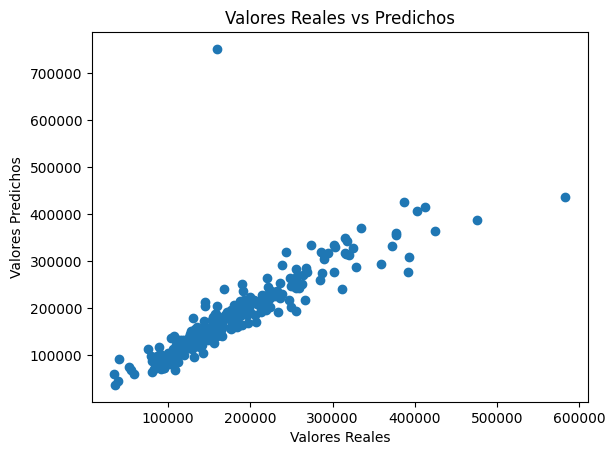

In [45]:
# Grafico de prueba frente a valores previstos
plt.scatter(y_test, y_pred)
plt.xlabel("Valores Reales")    
plt.ylabel("Valores Predichos")
plt.title("Valores Reales vs Predichos")


In [93]:
# Evaluación del modelo
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MAE: 18572.342695073665
MSE: 2149059290.055681
RMSE: 42582.79751412186
R2: 0.6954021950691709


* MAE- Error promedio absoluto entre lo real y lo predicho, cuanto en promedio me equivoco en esta caso por precio de vivienda
* RMSE- raiz del error cuadratico medio, siempre el RMSE>MAE entre mas lejos hay errores grandes entre mas cerca error uniformes.
* R2 coeficiente determinacion que tanto explica el modelo la variabilidad de los datos, siendo 1 perfecto 0 no explica nada, nos dice que tanto entiende el modelo

CONCLUSIONES
* El modelo presentaba un R2 de 0.64 inicialmente, es moderado la capacidad que tiene el modelo para interpretar el nivel del precio de la vivienda. Pero se investigo y algunos casos en los datos donde se tienen NaN, en realidad en muchos casos son información "No tiene", como por ejemplo no tiene garaje, no tiene sotano. Inicialmente se obto por usar un imputer donde rellenara las variables categoricas faltantes con las mas frecuentes, y nos arrojo este primer resultado, posteriormente se decide a ensayar en vez de rellenar valores faltantes por el más frecuente se cambian por "None" donde se aprecia que el R2 subio a 0.69, mejoro un poco se decide trabajarlos asi.


*  Al tener una gran diferencia entre el RMSE y MAE, existe errores grandes en ciertar observaciones pueden darse por algunos outliers, podrian eliminarse por medio de quantiles.

* Primer resultado usando imputer con "Most frecuent"

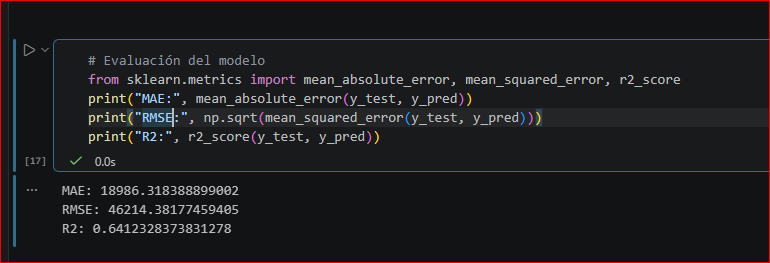


## Regularizaciones

In [53]:
# seguimos usando las variables por defecto
print("X_train:", X_train_processed.shape)
print("X_test:", X_test_processed.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("y_pred:", y_pred.shape)

X_train: (1168, 300)
X_test: (292, 300)
y_train: (1168,)
y_test: (292,)
y_pred: (292,)


In [94]:
# Regularizacion regresión Ridge 
# Ridge es una técnica de regularización que agrega una penalización a los coeficientes 
# del modelo para evitar el sobreajuste. La penalización se basa en la magnitud de los coeficientes, 
# lo que ayuda a reducir su impacto en la predicción y mejora la generalización del modelo.

#Importar función
from sklearn.linear_model import Ridge
#Crear instancia del modelo, alpha se prueba en escala logaritmica
lr_ridge = Ridge(alpha=1000)  # Alpha= 0 es regresion lineal normal Alpha pequeño poca penalizacion-alpha grande mucha penalizacion
#Entrenar
lr_ridge.fit(X_train_processed,y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1000
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


| alpha               | efecto                  |
| ------------------- | ----------------------- |
| 0                   | regresión lineal normal |
| muy pequeño (0.001) | casi sin regularización |
| medio (1 – 10)      | balance ideal           |
| grande (100+)       | modelo muy restringido  |


In [69]:
#Mostrar coeficientes
lr_ridge.coef_

array([-1.08284272e+03,  1.73453476e+03,  6.14778338e+03,  9.78062077e+03,
        6.56350062e+03,  8.28116212e+03,  1.45905411e+03,  5.42690958e+03,
        7.61564655e+03,  2.27534695e+03, -9.19354500e+02,  7.92379516e+03,
        6.59338927e+03,  1.31590598e+04, -1.99460213e+03,  1.56622609e+04,
       -5.08609065e+02, -9.27367980e+02,  1.11639166e+03,  2.46749272e+01,
       -3.70027848e+03, -3.18872728e+03,  2.95634129e+03,  3.84382744e+03,
        5.10746433e+02,  3.45209816e+03,  2.88621554e+03,  2.00264742e+03,
        5.41570978e+02, -5.21985865e+02,  8.30519593e+02,  1.79910470e+03,
        9.29884049e+03,  8.81968628e+02, -1.22788839e+03, -6.41589866e+02,
       -1.13018238e+04,  5.20541273e+03,  1.01131327e+04, -2.86371337e+02,
       -3.73035027e+03, -1.80702639e+04,  1.80702639e+04,  2.15318891e+03,
       -1.12341248e+03, -1.02977643e+03, -2.62924703e+03,  1.42608091e+03,
        4.20754446e+03, -3.00437833e+03, -6.31138808e+02,  4.94621843e+03,
       -9.45174251e+03,  

In [95]:
#Predecir
pred_ridge = lr_ridge.predict(X_test_processed)
#Calcular metricas
print('MAE:', mean_absolute_error(y_test, pred_ridge))
print('MSE:', mean_squared_error(y_test, pred_ridge))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_ridge)))
print('R2_score:', r2_score(y_test, pred_ridge))

MAE: 20543.200339969822
MSE: 1983453262.2847424
RMSE: 44535.97716773196
R2_score: 0.6668188968455679


CONCLUSION
* En este caso comparando el resultado con la regresion linea, para el caso de Ridge el RMSE dio mas alto y el R2 dió más bajo, esto indica un peor desempeño. la regularizacion realizada por Ridge no fue beneficiosa para este conjunto de datos. el modelo base no presenta problemas de overfiting.
* Ridge no mejoró el modelo, ya que aumentó el error y redujo la capacidad explicativa, indicando que la regularización no era necesaria en este caso, teniendo en cuenta que se itero para varios  hiperparámetros encontrando  el óptimo.


In [ ]:
# Regresión Lasso 
# Es bueno cuando se tiene muchas variables y cuando se tiene sospecha de overfitting.

#Importar función
from sklearn.linear_model import Lasso
#Crear instancia del modelo
lr_lasso = Lasso(alpha=0.1)
#Entrenar
lr_lasso.fit(X_train_processed,y_train)

c:\Users\Usuario\Desktop\Aprendizaje de Maquinas\Tarea1\Parte 1 - Regresión\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.187e+11, tolerance: 7.469e+08
  model = cd_fast.sparse_enet_coordinate_descent(


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [97]:
#Mostrar coeficientes
print('Coefficients: \n', lr_lasso.coef_)

Coefficients: 
 [-1.32943865e+03  1.85831803e+03  6.31279557e+03  9.93797059e+03
  6.53510353e+03  8.33272303e+03  1.64651661e+03  5.56257268e+03
  1.27091125e+04  4.28505779e+03  4.32355642e+03  3.38955392e+03
  1.50601281e+04  2.29333154e+04 -9.36848559e+02  3.48506966e+03
 -3.58270597e+02 -8.28853499e+02  1.14414931e+03  6.64181682e+01
 -3.74163778e+03 -3.14876903e+03  3.00685667e+03  3.64844940e+03
  4.61070383e+02  3.00154936e+03  3.19312973e+03  1.88224250e+03
  3.78670196e+02 -4.27289063e+02  8.39125432e+02  1.94267980e+03
  3.25965552e+04  3.69739966e+02 -1.23636272e+03 -6.77059890e+02
 -9.51113552e+03  6.04861645e+03  1.05739549e+04  5.12675593e+02
 -2.76402156e+03 -3.58288473e+04  0.00000000e+00  3.21398219e+03
 -7.92025014e+01  0.00000000e+00 -1.22978719e+02  4.46722771e+03
  6.04788987e+03 -3.43858566e+02 -4.45145451e+03  3.98307942e+02
 -1.53840663e+04  4.49588170e+02  4.40274124e+04 -7.26867476e-03
  2.12263419e+03  1.04735601e+04 -7.18405885e+03 -1.62398238e+04
  0.00000

In [114]:
#Predecir
pred_lasso = lr_lasso.predict(X_test_processed)
#Calcular metricas
print('MAE:', mean_absolute_error(y_test, pred_lasso))
print('MSE:', mean_squared_error(y_test, pred_lasso))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_lasso)))
print('R2_score:',r2_score(y_test, pred_lasso))

MAE: 18510.694096619594
MSE: 1758313448.4377067
RMSE: 41932.248311266434
R2_score: 0.7046379536229039


CONCLUSION
* El modelo Lasso presento una breve mejora frente a la regresión lineal y Ridge, se vió en la reducción del RMSE y el aumento del R². Esto indica que la regularización L1 permitió eliminar variables irrelevantes, reduciendo el ruido del modelo y al mismo tiempo mejorando su capacidad de generalización.
* Laso mejoró un poco modelo, ya que disminuyo el error y aumento la capacidad explicativa, indicando que en este caso la regularización ayudo un poco en la mejora del modelo, teniendo en cuenta que se itero para varios  hiperparámetros encontrando  el óptimo.

In [128]:
# Elastic Net
# Es una combinación de Ridge y Lasso, lo que permite controlar la cantidad de penalización 
#Importar función
from sklearn.linear_model import ElasticNet
#Crear instancia del modelo
lr_elastic = ElasticNet(alpha=0.2, l1_ratio=0.2)
#Entrenar
lr_elastic.fit(X_train_processed,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.2
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.2
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [117]:
#Mostrar coeficientes
print('Coefficients: \n', lr_elastic.coef_)

Coefficients: 
 [-2.84480509e+03  2.72863051e+03  3.84433941e+03  1.32527099e+04
  5.65262513e+03  4.27159981e+03  2.12754304e+03  6.79985549e+03
  7.75457427e+03  8.16518204e+02  2.07645096e+02  8.65783095e+03
  7.15999688e+03  7.66568319e+03 -1.42942776e+03  1.15038958e+04
  9.36646911e+02 -9.83568686e+02  2.61416870e+03  2.00091380e+03
 -3.29754882e+03 -3.20659851e+03  4.66497148e+03  3.56200582e+03
  1.84378975e+03  4.08854688e+03  3.80000497e+03  2.71922853e+03
  5.32171825e+02 -1.07263054e+02  4.11111067e+02  1.22499359e+03
  3.45525348e+03 -2.69805640e+02 -4.62726653e+02 -2.80215562e+02
 -7.09441958e+02  9.83790425e+02  4.37558588e+02  1.17358055e+03
 -1.88573757e+03 -7.87290436e+02  7.87290436e+02 -2.06509742e+02
 -1.70321962e+02  3.77081678e+02  4.63472235e+02  1.18276864e+03
 -3.01807445e+01 -1.61606012e+03 -1.24195053e+03  6.63365284e+02
 -1.44575615e+02  7.23160889e+02  1.87787178e+02 -1.87787178e+02
 -2.09507490e+02  2.75999717e+03 -6.03835661e+02 -1.76456278e+02
 -1.76944

In [127]:
#Predecir
pred_elastic= lr_elastic.predict(X_test_processed)
#Calcular metricas
print('MAE:', mean_absolute_error(y_test, pred_elastic))
print('MSE:', mean_squared_error(y_test, pred_elastic))
print('RMSE:', np.sqrt(mean_squared_error(y_test, pred_elastic)))
print('R2_score:',r2_score(y_test, pred_elastic))

MAE: 18043.9738604434
MSE: 2201363574.413359
RMSE: 46918.69109868006
R2_score: 0.6302142540418818


CONCLUSION
* El modelo ElasticNet no mejoró el desempeño frente a Lasso ni a la regresión lineal, evidenciado en un mayor RMSE y menor R². Esto sugiere que la combinación de regularizaciones L1 y L2 no fue adecuada para este conjunto de datos.
* la regularización L1 (Lasso) resultó más efectiva en la selección de variables y reducción del error.